# Overview

**EnergyFM** is a family of **domain-specific Time Series Foundation Models (TSFMs)** for energy meter data analytics. Pretrained on **1.26 billion hourly electricity consumption readings** from **76,000+ buildings**, EnergyFM provides powerful representations for a wide range of downstream energy applications while remaining lightweight and computationally efficient.

The project currently includes two pretrained models:

* **Energy-TTM** – A forecasting foundation model built upon IBM Research's **Tiny Time Mixer (TTM)** architecture, optimized for **short-term load forecasting**.
* **Energy-TSPulse** – A reconstruction-based foundation model adapted from IBM Research's **TSPulse** architecture for **energy anomaly detection**, **appliance classification**, and **missing value imputation**.

EnergyFM supports both **zero-shot inference** and **task-specific fine-tuning**, enabling practitioners to deploy pretrained models on new buildings with minimal labeled data.

### Resources

* **Project Website:** https://energyfms.github.io/
* **Paper:** https://dl.acm.org/doi/10.1145/3744255.3798119
* **GitHub Repository:** https://github.com/energyfms
* **Hugging Face Models:** https://huggingface.co/EnergyFM
* **Tutorial Notebooks:** https://github.com/energyfms/notebooks

If you use **EnergyFM** in your research or applications, please consider citing our paper


# Zero-Shot Short-Term Load Forecasting with EnergyTTM

In this notebook, we evaluate its **zero-shot forecasting** capability, making accurate predictions on previously unseen buildings **without any task-specific fine-tuning**.

<a target="_blank" href="https://colab.research.google.com/github/energyfms/notebooks/blob/main/energy_ttm_zeroshot.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### What is Short-Term Load Forecasting (STLF)?

**Short-Term Load Forecasting (STLF)** aims to predict future electricity demand over the next few hours or days using historical consumption patterns. Accurate STLF is essential for:

- Power grid operation and balancing
- Demand response and energy optimization
- Building energy management systems
- Reducing operational costs and improving sustainability

This notebook focuses on the common **day-ahead forecasting** setting, where the model predicts the **next 24 hours** of electricity demand from the **previous 7 days** of observations.


### Experiment Setup

In this notebook, you will:

- Load a pretrained **EnergyTTM** checkpoint
- Generate **24-hour forecasts** using **zero-shot inference**
- Compare predictions against ground truth
- Evaluate forecasting performance using standard metrics

No model training or fine-tuning is required.



| Setting | Value |
|---------|-------|
| Model | **EnergyTTM (Pretrained)** |
| Inference | Zero-Shot (No Fine-Tuning) |
| Context Length | **168 hours** (Previous 7 days) |
| Forecast Horizon | **24 hours** (Next day) |
| Evaluation |Rolling forecat on last 6 months of data  |
| Metric |MAE and RMSE  |






### Install Granite-TSFM dependencies

In [1]:
# ! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

In [2]:
import os
import random 
import math 
import tempfile 
import torch 
import pickle 
import logging 
import warnings
import json
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np 
import pandas as pd
from transformers import  set_seed
from torch.utils.data import ConcatDataset, Dataset, DataLoader
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/energyfms/notebooks/refs/heads/main/Dataset/Forecasting/sample_building_275_ashrae.csv")

In [4]:
df.head()

,building_id,meter,timestamp,meter_reading
0,275,0,2016-01-01 00:00:00,88.10
1,275,0,2016-01-01 01:00:00,91.88
2,275,0,2016-01-01 02:00:00,92.60
3,275,0,2016-01-01 03:00:00,95.39
4,275,0,2016-01-01 04:00:00,95.51


In [5]:

# Set index
df.set_index("timestamp", inplace=True)
df.index = pd.to_datetime(df.index)
# Ensure numeric
df["meter_reading"] = pd.to_numeric(df["meter_reading"], errors="coerce")


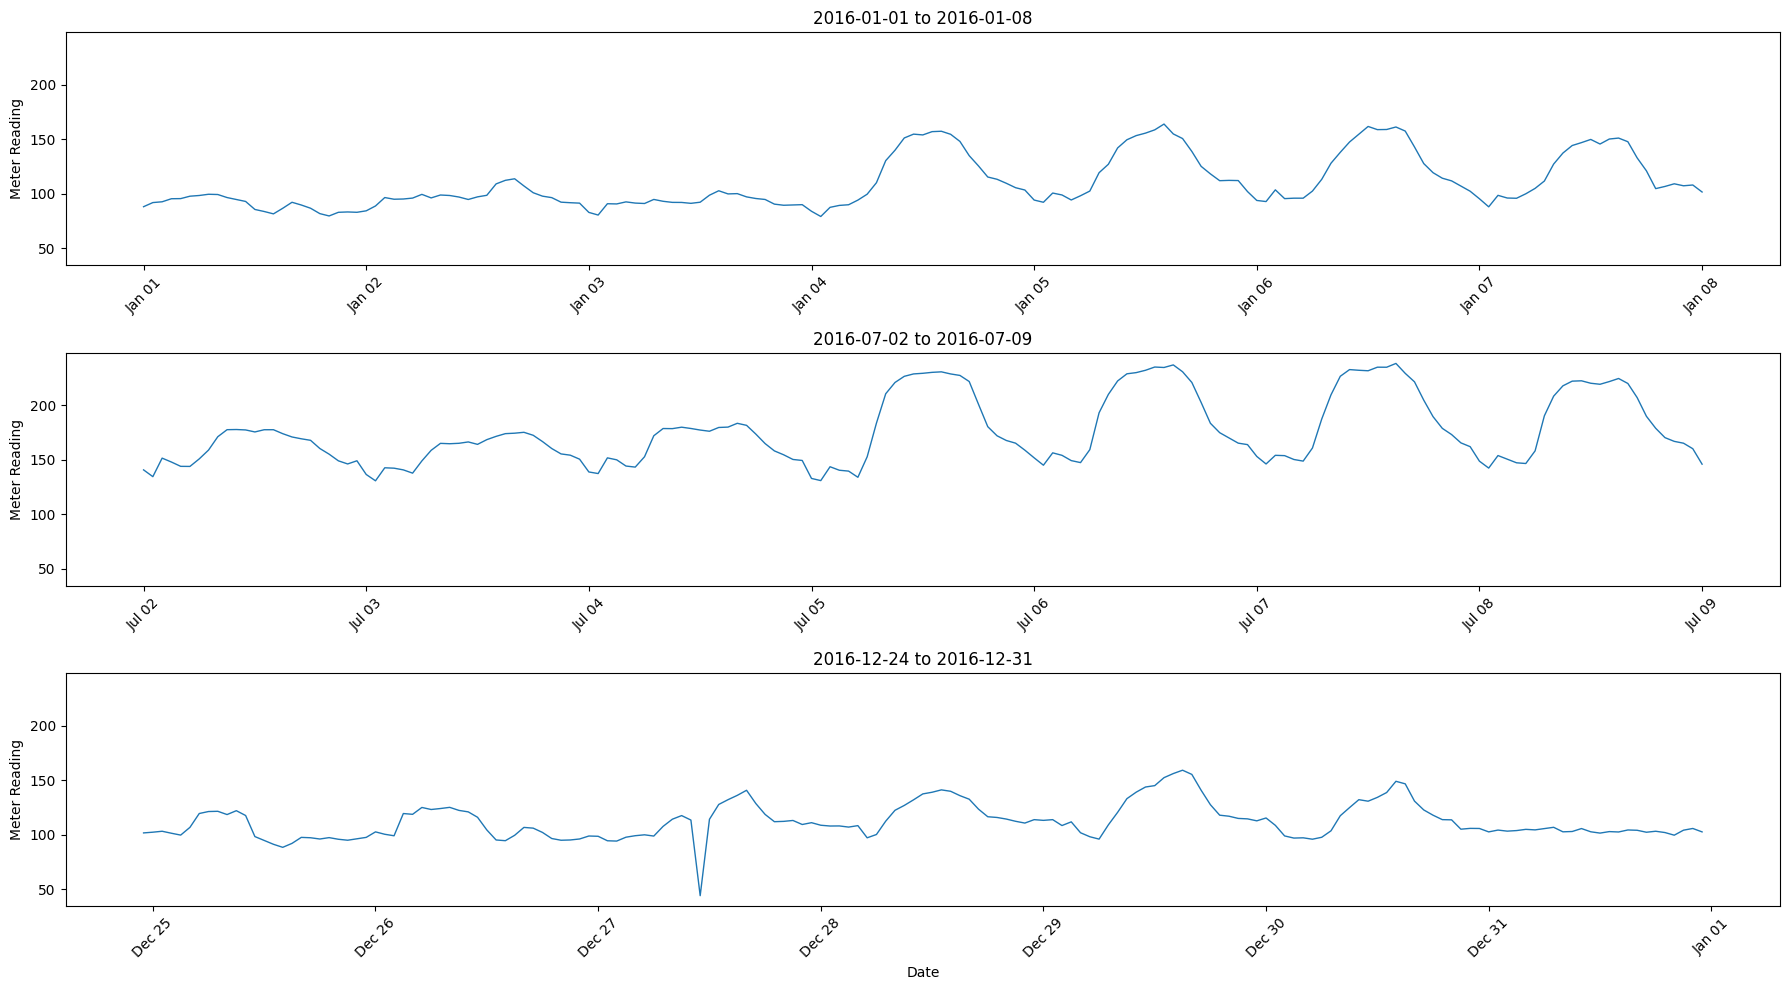

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Number of weeks to display
num_windows = 3
window = pd.Timedelta(days=7)

# Starting indices (beginning, middle, end)
starts = [
    df.index[0],
    df.index[len(df)//2],
    df.index[-1] - window
]

fig, axes = plt.subplots(num_windows, 1, figsize=(18, 10), sharey=True)

for ax, start in zip(axes, starts):
    end = start + window
    week = df.loc[start:end]

    ax.plot(week.index, week["meter_reading"], linewidth=1)

    ax.set_title(f"{start.date()} to {end.date()}")
    ax.set_ylabel("Meter Reading")

    # Tick every day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    plt.setp(ax.get_xticklabels(), rotation=45)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

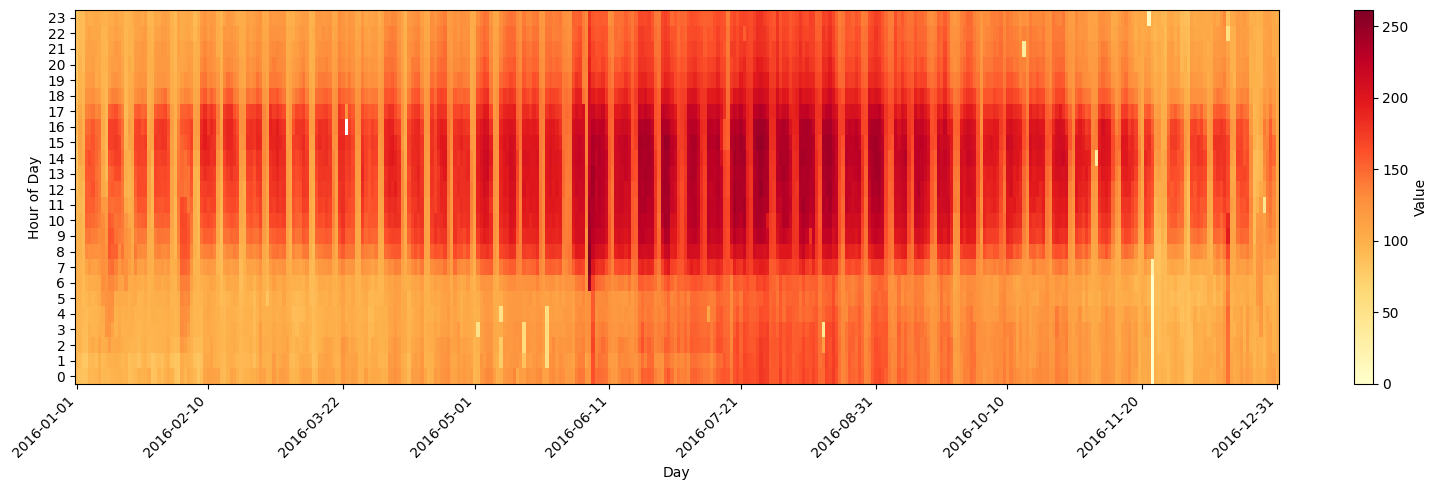

In [7]:

heatmap = df.copy()
heatmap["day"] = heatmap.index.date
heatmap["hour"] = heatmap.index.hour

# Hours × Days
heatmap = heatmap.pivot_table(
    index="hour",
    columns="day",
    values="meter_reading"
)

fig, ax = plt.subplots(figsize=(16, 5))

im = ax.imshow(
    heatmap.values,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="YlOrRd"
)

# Hour labels
ax.set_yticks(np.arange(24))
ax.set_ylabel("Hour of Day")

# Show about 10 evenly spaced day labels
xticks = np.linspace(0, heatmap.shape[1]-1, 10, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels(
    [str(heatmap.columns[i]) for i in xticks],
    rotation=45,
    ha="right"
)
ax.set_xlabel("Day")

plt.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.show()

In [8]:
print(df.isna().sum())
df.describe()

building_id      0
meter            0
meter_reading    0
dtype: int64


,building_id,meter,meter_reading
count,8783.0,8783.0,8783.000000
mean,275.0,0.0,146.212743
std,0.0,0.0,38.432772
min,275.0,0.0,0.000000
25%,275.0,0.0,114.835000
50%,275.0,0.0,141.450000
75%,275.0,0.0,171.620000
max,275.0,0.0,261.240000


## Baseline Model: Seasonal Naive

In [9]:
context_length = 168
horizon = 24
season_length = 24

# Actual values corresponding to model predictions
actual = df["meter_reading"].iloc[context_length:].values

# Seasonal naive prediction (value from 24 hours ago)
sn_pred = (
    df["meter_reading"]
    .shift(season_length)
    .iloc[context_length:]
    .values
)

# Remove NaNs if any
mask = ~np.isnan(sn_pred)

actual = actual[mask]
sn_pred = sn_pred[mask]
time_index = df.index[context_length:][mask]

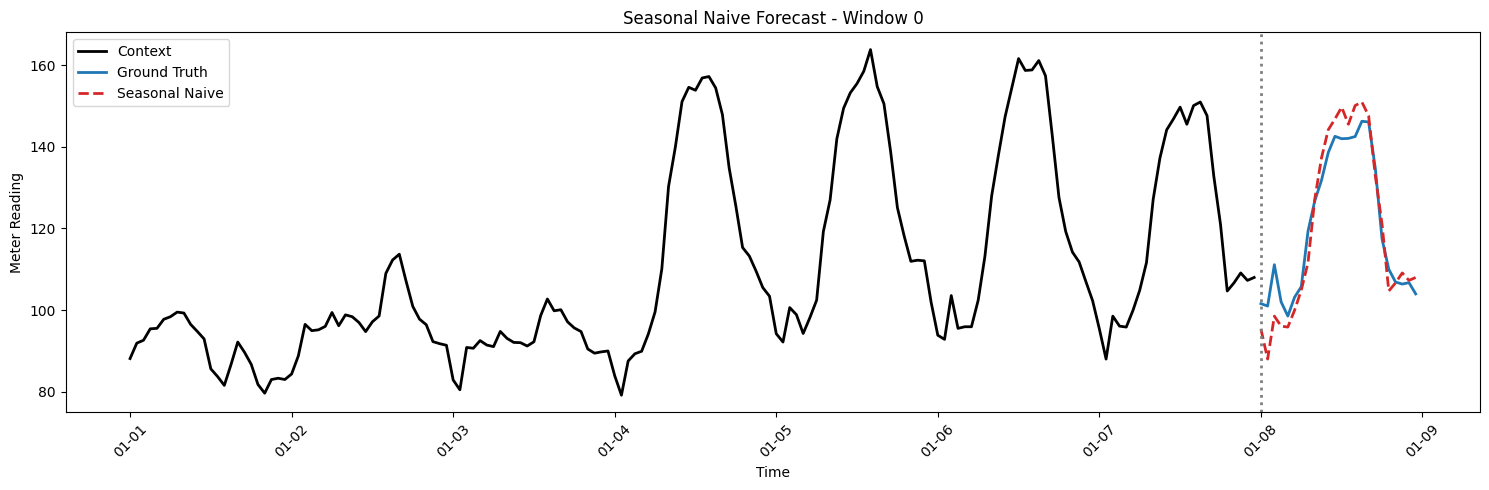

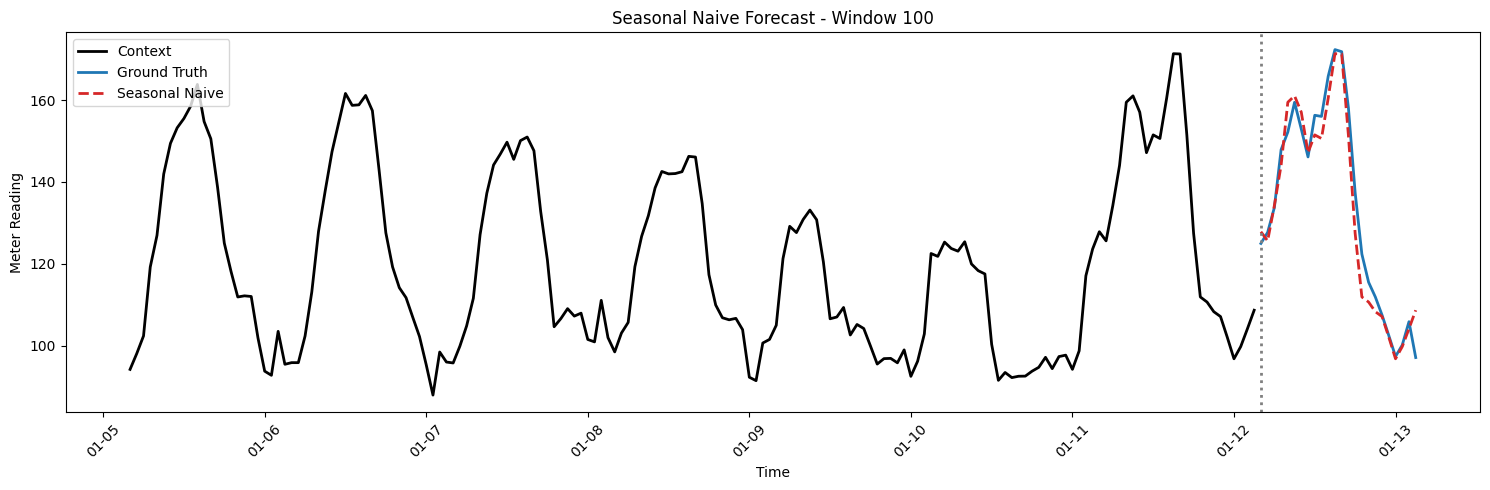

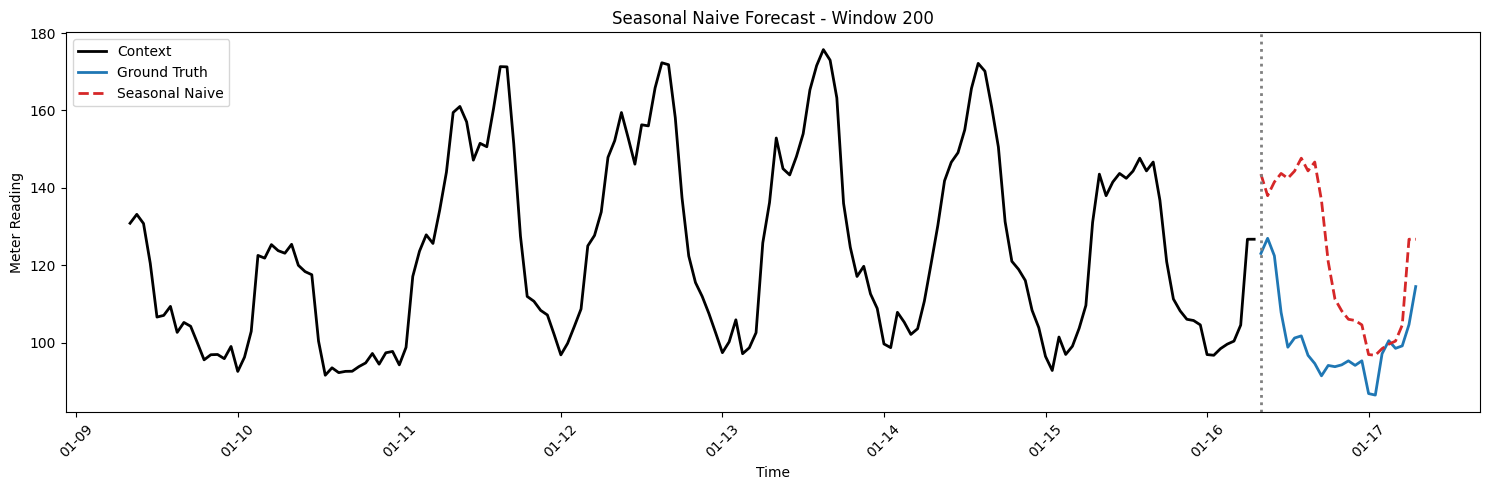

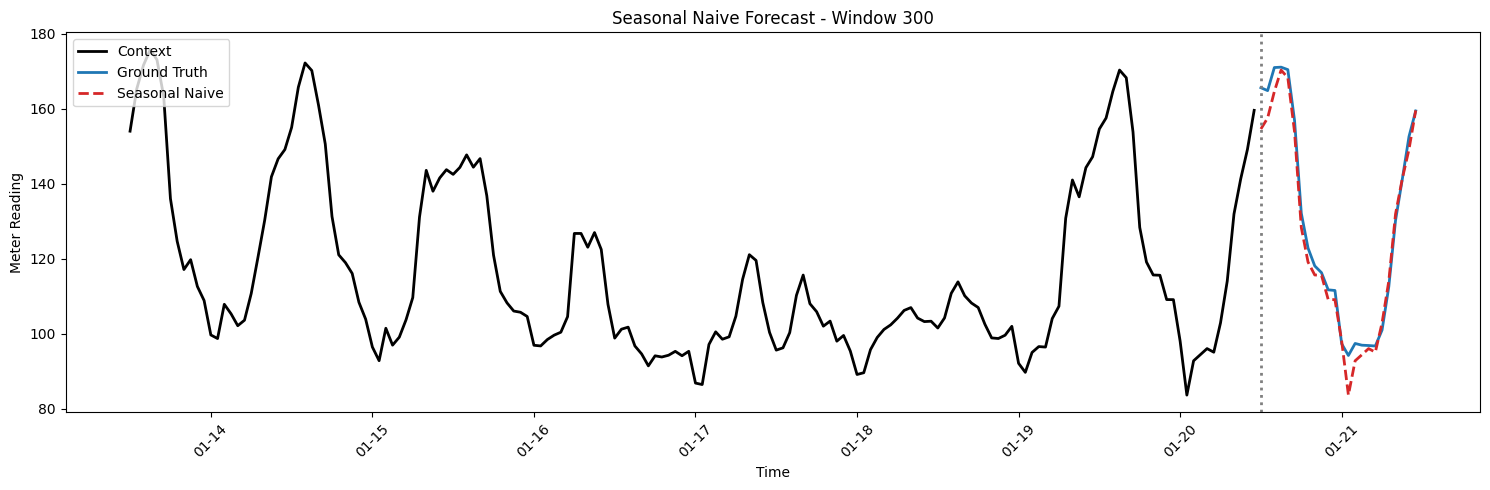

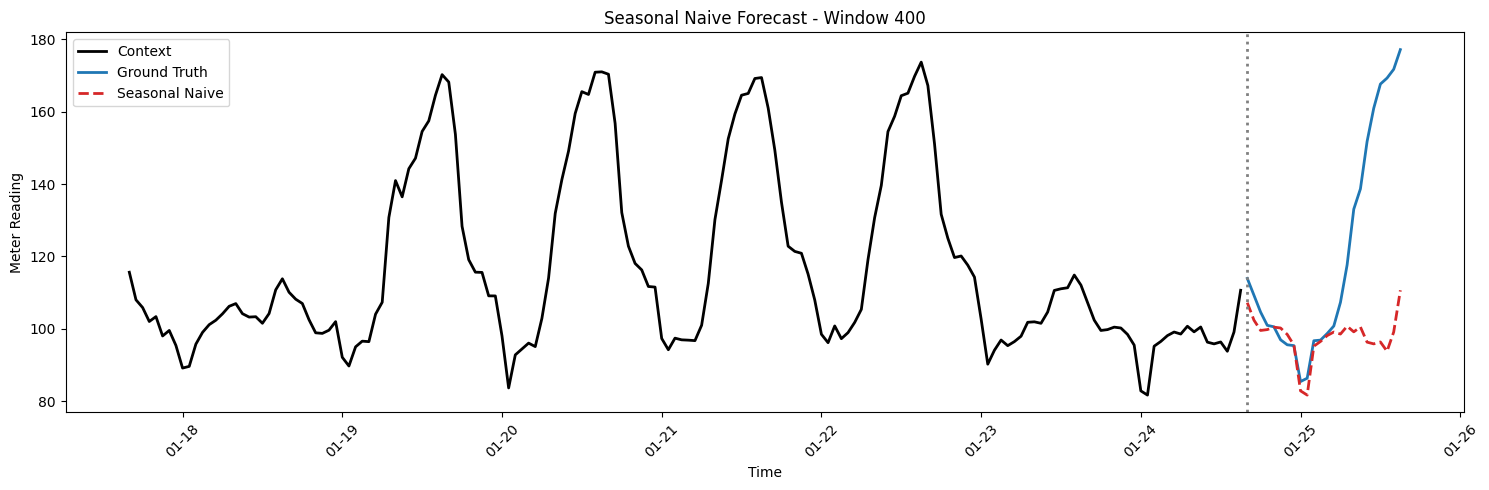

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

context_length = 168
horizon = 24
season_length = 24

n_plots = 5
window_stride = 100

for i in range(n_plots):

    window = i * window_stride

    # Beginning of forecast
    forecast_start = context_length + window

    if forecast_start + horizon > len(df):
        break

    # ---------------- Context ----------------
    context_time = df.index[
        forecast_start - context_length : forecast_start
    ]

    context = df["meter_reading"].iloc[
        forecast_start - context_length : forecast_start
    ].values

    # ---------------- Forecast ----------------
    forecast_time = df.index[
        forecast_start : forecast_start + horizon
    ]

    actual = df["meter_reading"].iloc[
        forecast_start : forecast_start + horizon
    ].values

    seasonal_naive = sn_pred[forecast_start - context_length : forecast_start - context_length + horizon]

    fig, ax = plt.subplots(figsize=(15, 5))

    # Historical context
    ax.plot(
        context_time,
        context,
        color="black",
        linewidth=2,
        label="Context",
    )

    # Ground truth
    ax.plot(
        forecast_time,
        actual,
        color="tab:blue",
        linewidth=2,
        label="Ground Truth",
    )

    # Seasonal naive forecast
    ax.plot(
        forecast_time,
        seasonal_naive,
        "--",
        color="tab:red",
        linewidth=2,
        label="Seasonal Naive",
    )

    # Forecast boundary
    ax.axvline(
        x=forecast_time[0],
        color="gray",
        linestyle=":",
        linewidth=2,
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    plt.xticks(rotation=45)
    plt.title(f"Seasonal Naive Forecast - Window {window}")
    plt.xlabel("Time")
    plt.ylabel("Meter Reading")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## EnergyTTM

#### Loading EnergyTTM (168-24-commercial)
The current variant is pretrained on synthetic commercial data, and is inteded to be used for commercial building data. User may experiment with other variants depending on use case.

In [11]:

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
args = {
    "num_input_channels": 1,
    "context_length": 168,  # 1 week of hourly data
    "prediction_length": 24,   # Forecasting next 24 hours
    "patch_stride": 24,
}


# Initialize Model

ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    "EnergyFM/energy-ttm",  # Name of the model on Hugging Face
    revision="168-24-comm", # model revision: 168-24-res, 512-96-comm, 512-96-res
    num_input_channels=1,  # tsp.num_input_channels 
).to(device)

#### Helper function for pre-processing and evaluation

In [12]:

def standardize_series(series, eps=1e-8):
    mean = np.mean(series)
    std = np.std(series)
    standardized_series = (series - mean) / (std+eps)
    return standardized_series, mean, std

def unscale_predictions(predictions, mean, std, eps=1e-8):
    return predictions * (std+eps) + mean




### Custom Torch Dataset for EnergyTTM

In [13]:

class TimeSeriesDataset(Dataset):
    def __init__(self, data, backcast_length, forecast_length, stride=1):
        # Standardize the time series data
        self.data, self.mean, self.std = standardize_series(data)
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.backcast_length - self.forecast_length) // self.stride + 1

    def __getitem__(self, index):
        start_index = index * self.stride
        x = self.data[start_index : start_index + self.backcast_length]
        y = self.data[start_index + self.backcast_length : start_index + self.backcast_length + self.forecast_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [14]:
def create_dataset_if_valid(energy_data, args):

    # Minimum required length to form at least one training sample
    min_required = args["context_length"] + args["prediction_length"]

    # Skip if series is too short
    if len(energy_data) < min_required:
        print("   Too short, skipping...")
        return None

    # Create dataset using sliding windows
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"]
    )

    # Ensure dataset contains at least one sample
    if len(dataset) == 0:
        print("   No samples, skipping...")
        return None

    return dataset



#### Intialising Test Dataset

In [15]:
test_dataset = create_dataset_if_valid(df["meter_reading"].values, args)  
print("Test size:", len(test_dataset))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Test size: 358


### Inferencing TTM

In [16]:

ttm_model.eval()

criterion = nn.MSELoss()

val_losses = []
y_true_test = []
y_pred_test_ttm = []

# Iterate over dataset one sample at a time
for x_test, y_test in test_loader:

    # Add channel dimension and move to device
    x_test = x_test.unsqueeze(-1).to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        # Forward pass
        output = ttm_model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_test)

        # Skip if loss is NaN
        if torch.isnan(loss):
            continue

        # Store results
        val_losses.append(loss.item())
        y_true_test.append(y_test.cpu().numpy())
        y_pred_test_ttm.append(forecast.cpu().numpy())

# If no valid predictions collected
if len(y_true_test) == 0:
    y_true_test = np.array([])
    y_pred_test_ttm = np.array([])

# Concatenate predictions and ground truth
y_true_ttm = np.concatenate(y_true_test, axis=0)
y_pred_ttm = np.concatenate(y_pred_test_ttm, axis=0)



In [17]:
mean = test_dataset.mean
std  = test_dataset.std

y_true_flat = y_true_ttm.reshape(-1)
y_pred_flat = y_pred_ttm.reshape(-1)


y_true_unscaled = unscale_predictions(y_true_flat, mean, std)
y_pred_unscaled_ttm = unscale_predictions(y_pred_flat, mean, std)


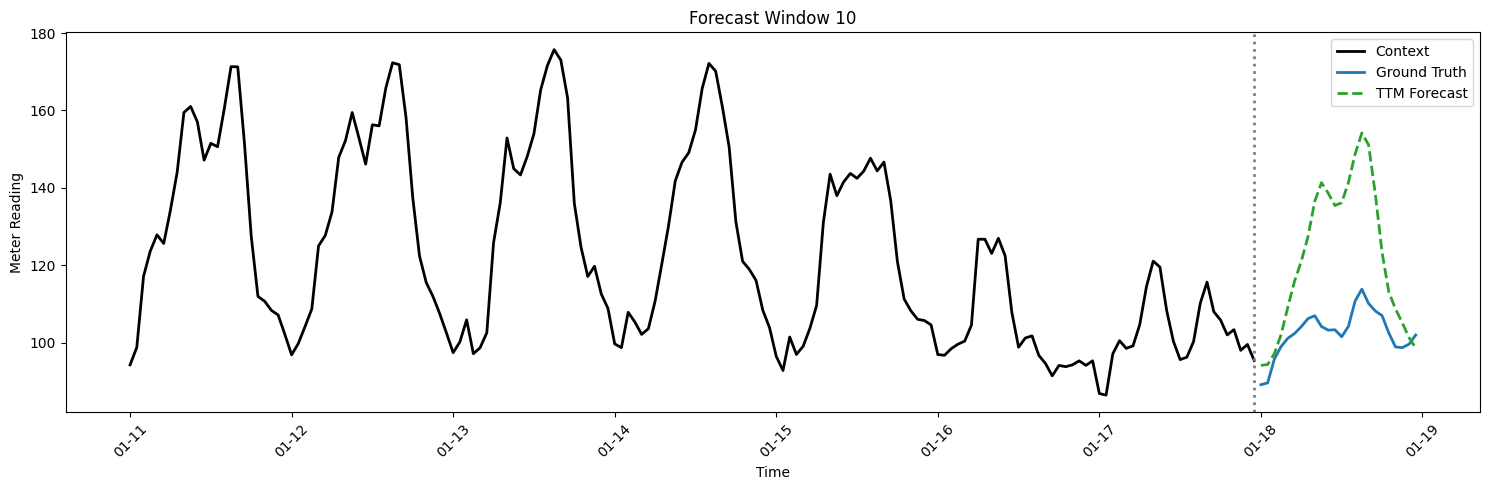

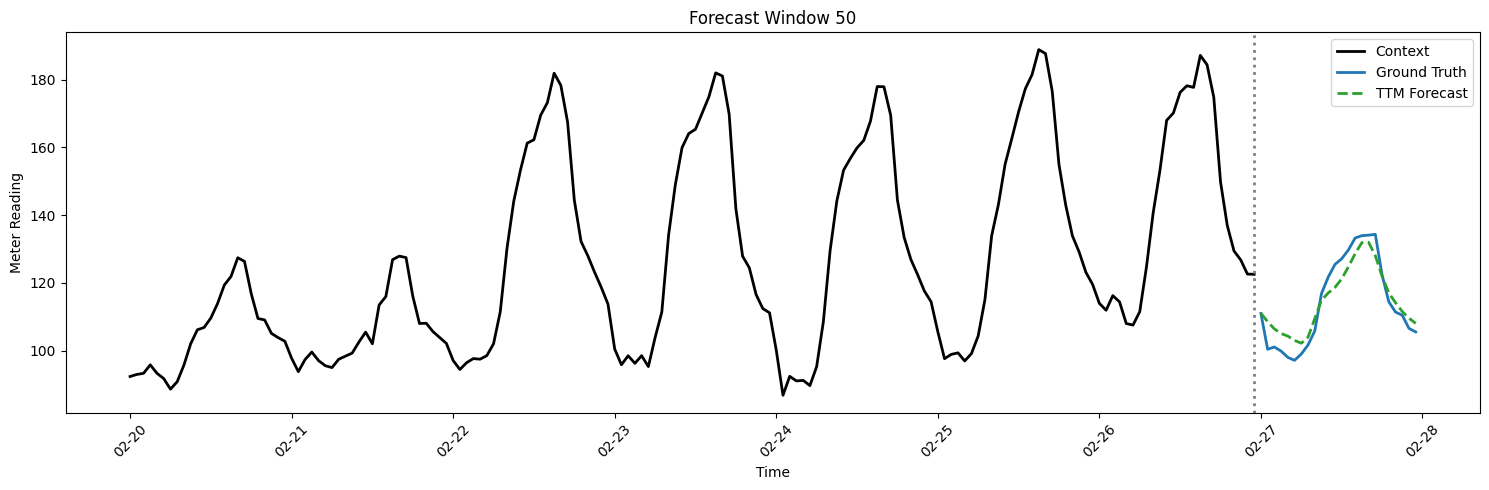

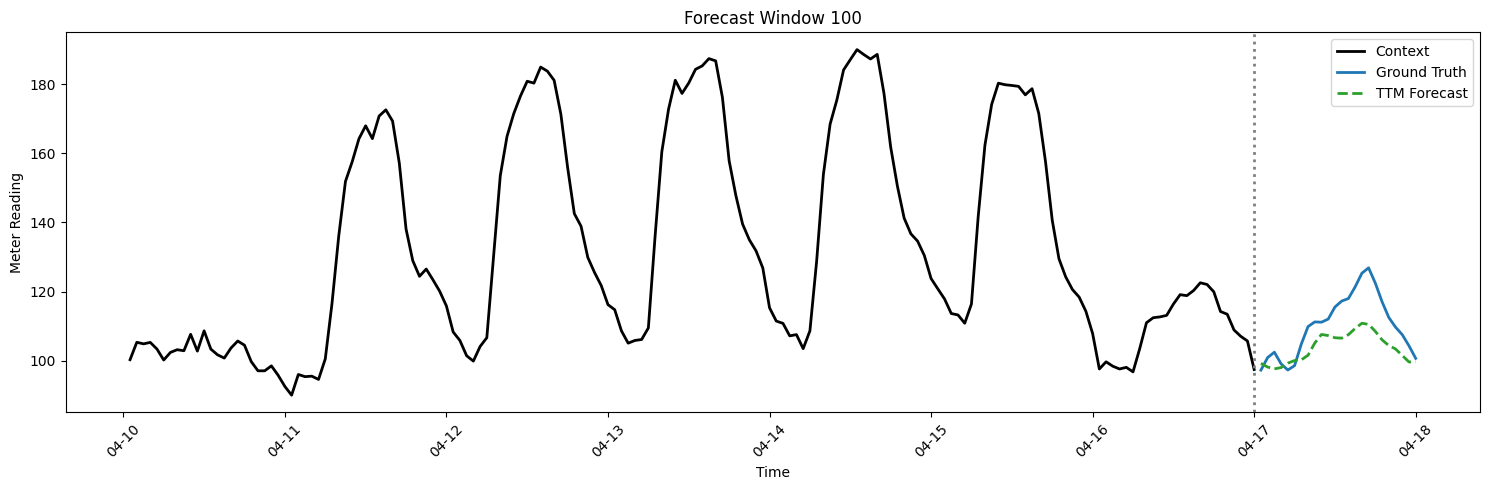

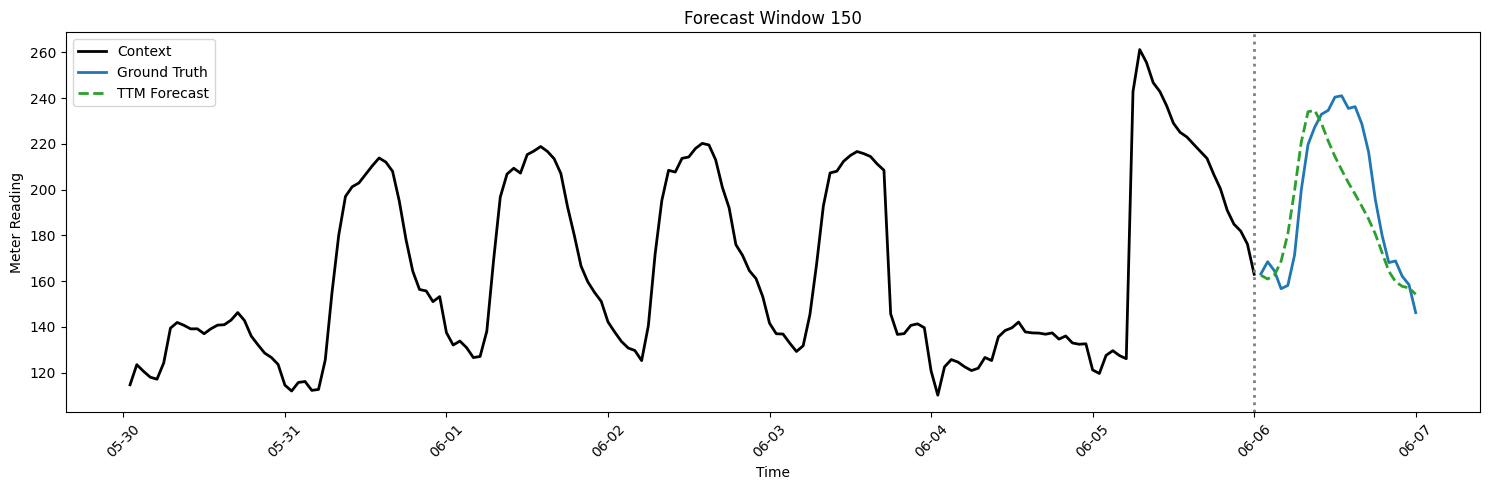

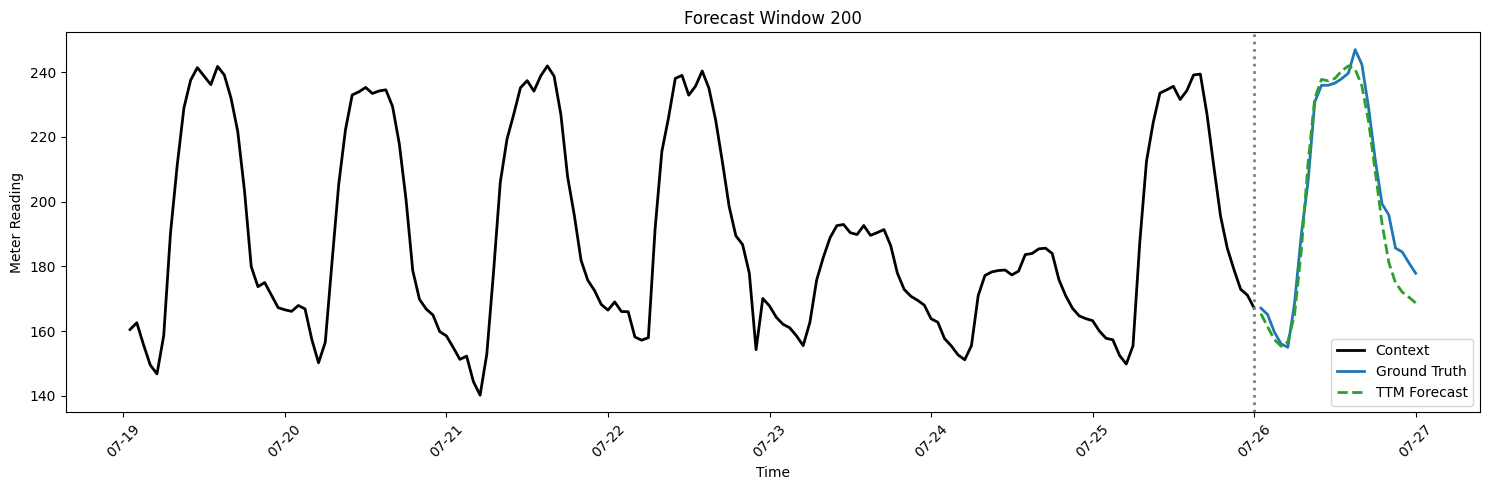

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

context_length = 168
horizon = 24

# These are 1D arrays
# y_true_unscaled.shape == (N * horizon,)
# y_pred_unscaled_ttm.shape == (N * horizon,)

window_ids = [10, 50 , 100, 150 , 200]

for window in window_ids:

    # Start of the forecast in the original dataframe
    forecast_start = context_length + window * horizon

    # Stop if we run past the end
    if forecast_start + horizon > len(df):
        break

    # ---------------- Context ----------------
    context_time = df.index[
        forecast_start - context_length : forecast_start
    ]
    context = df["meter_reading"].iloc[
        forecast_start - context_length : forecast_start
    ].values

    # ---------------- Forecast ----------------
    pred_start = window * horizon
    pred_end = pred_start + horizon

    actual = y_true_unscaled[pred_start:pred_end]
    pred = y_pred_unscaled_ttm[pred_start:pred_end]

    forecast_time = df.index[
        forecast_start : forecast_start + horizon
    ]

    fig, ax = plt.subplots(figsize=(15, 5))

    # Context
    ax.plot(
        context_time,
        context,
        color="black",
        linewidth=2,
        label="Context",
    )

    # Ground truth
    ax.plot(
        forecast_time,
        actual,
        color="tab:blue",
        linewidth=2,
        label="Ground Truth",
    )

    # TTM forecast
    ax.plot(
        forecast_time,
        pred,
        "--",
        color="tab:green",
        linewidth=2,
        label="TTM Forecast",
    )

    # Forecast boundary
    ax.axvline(
        context_time[-1],
        color="gray",
        linestyle=":",
        linewidth=2,
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    plt.xticks(rotation=45)
    plt.title(f"Forecast Window {window}")
    plt.xlabel("Time")
    plt.ylabel("Meter Reading")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Visualising Forecasts

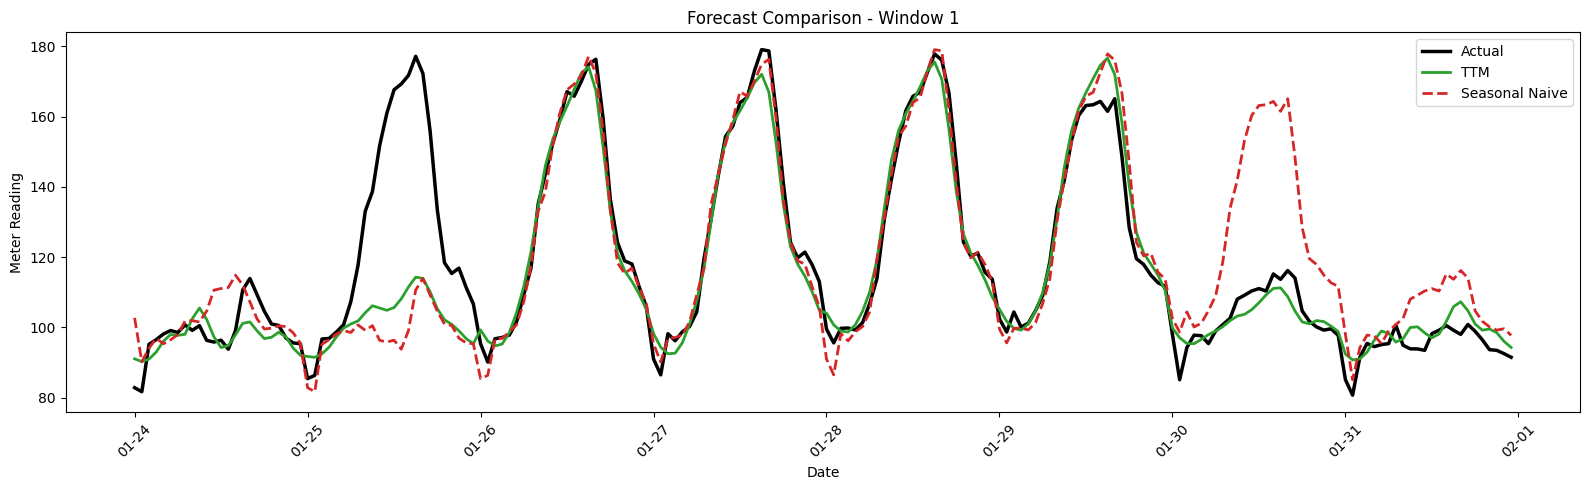

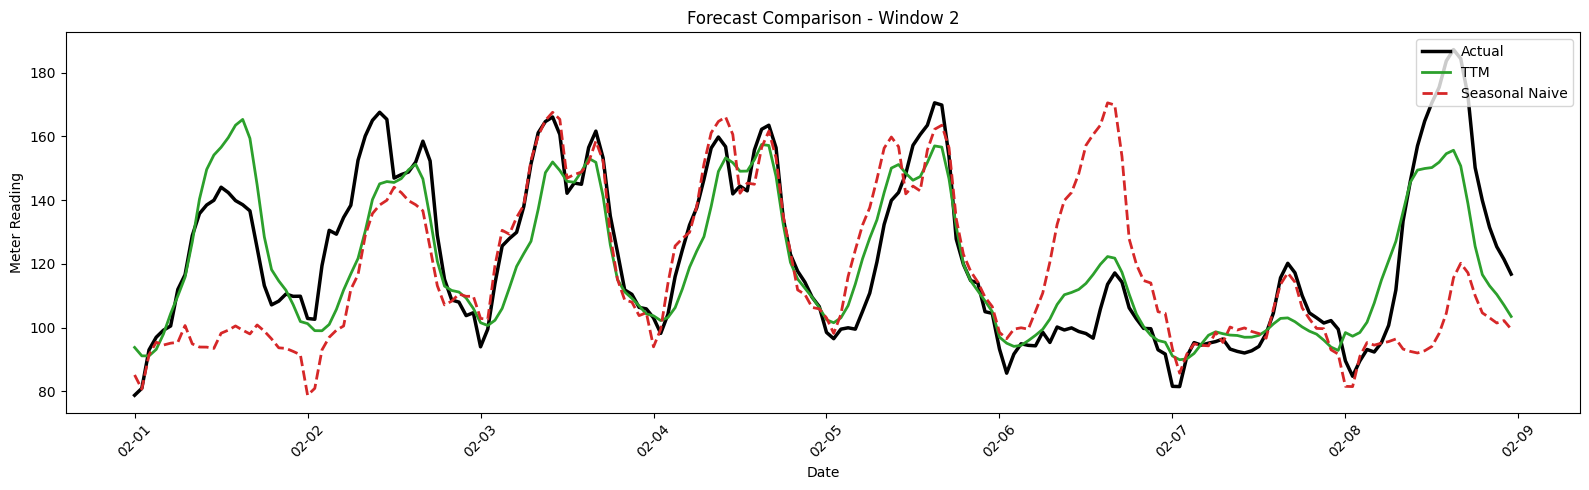

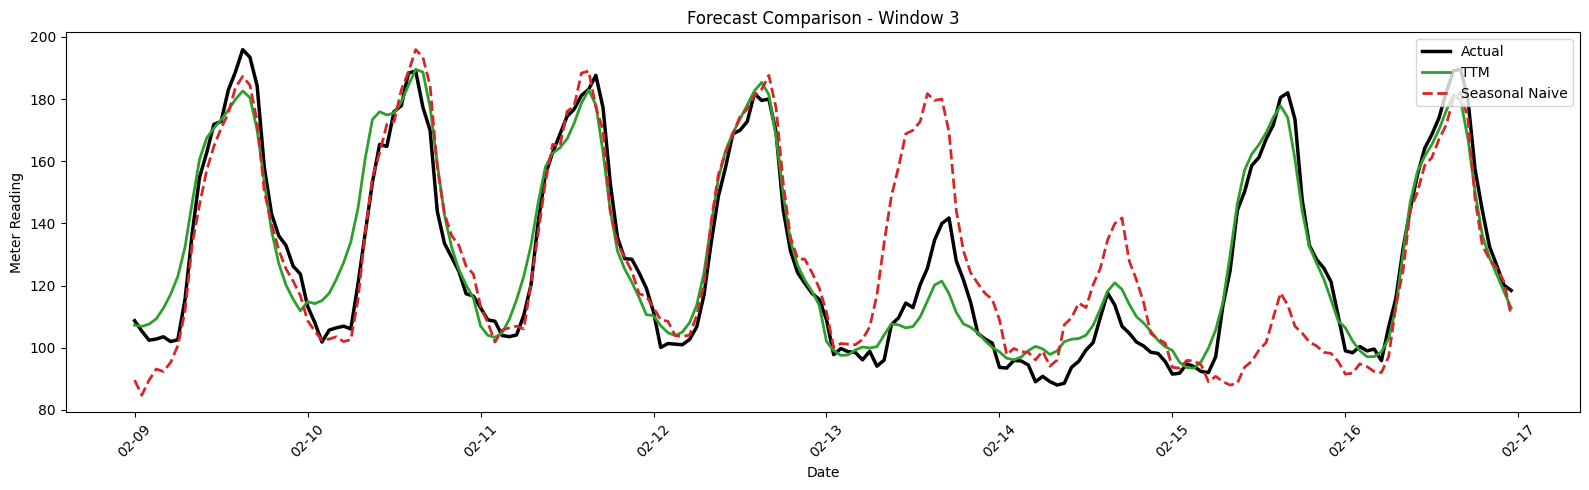

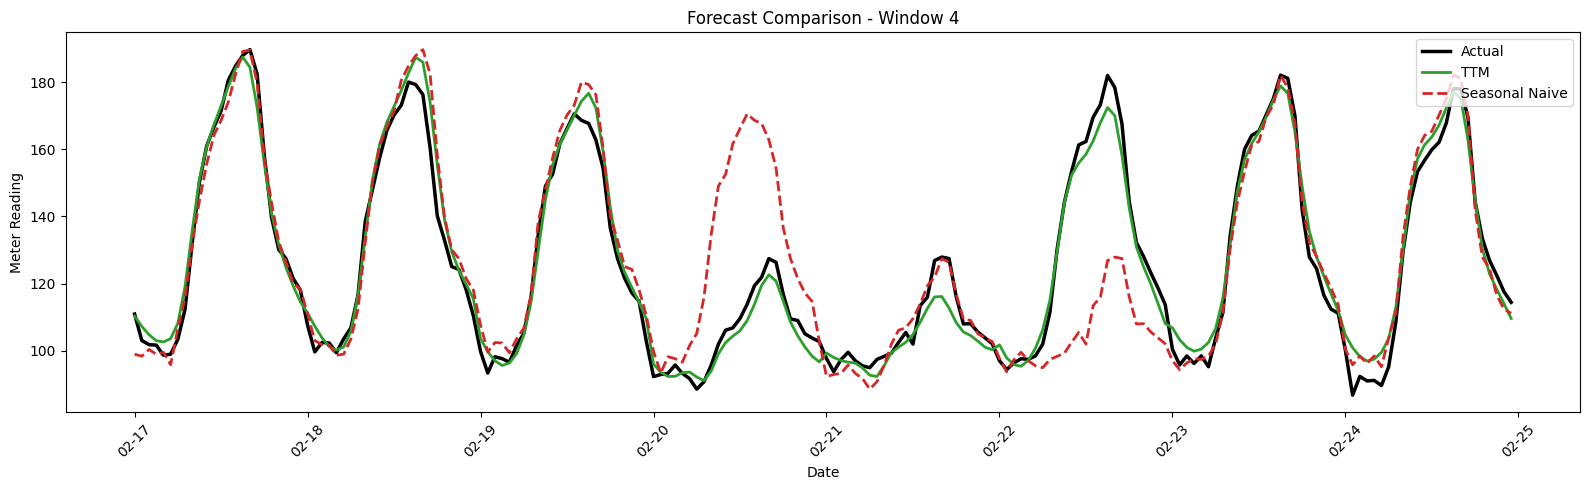

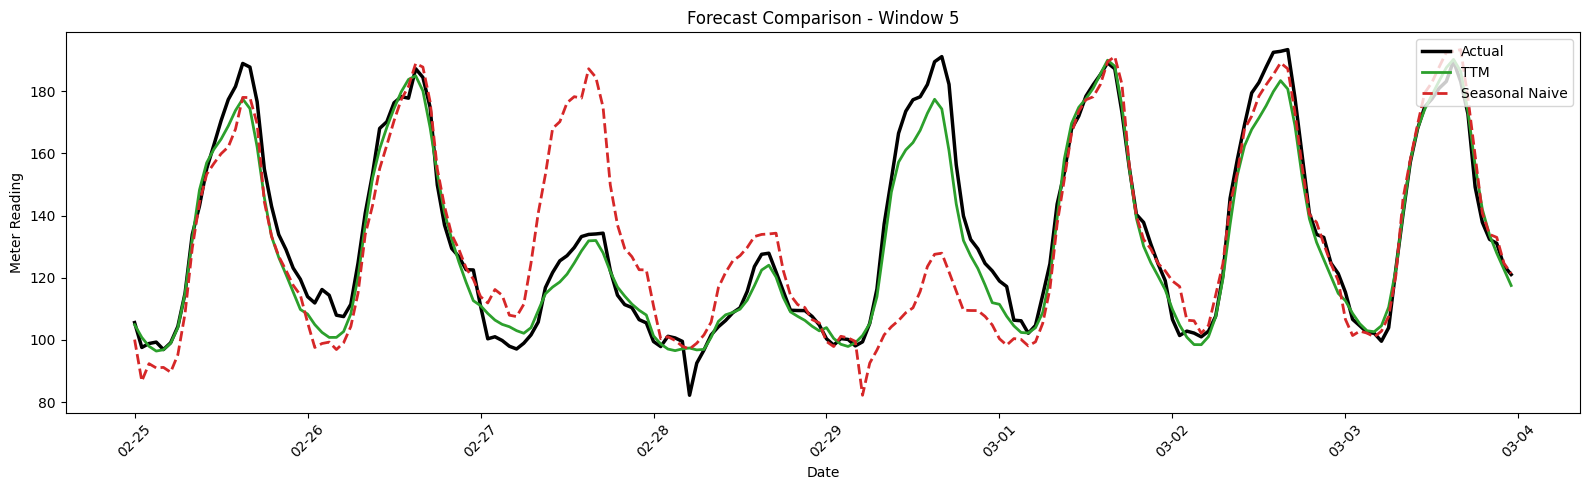

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Time index corresponding to predictions
model_time_index = df.index[168:]

actual = df["meter_reading"].iloc[168:].values
ttm_pred = np.asarray(y_pred_unscaled_ttm)

# Seasonal Naive
# season_length = 24
# sn_pred = df["meter_reading"].shift(season_length).iloc[168:].values

# Align lengths
min_len = min(
    len(model_time_index),
    len(actual),
    len(ttm_pred),
    len(sn_pred),
)

model_time_index = model_time_index[:min_len]
actual = actual[:min_len]
ttm_pred = ttm_pred[:min_len]
sn_pred = sn_pred[:min_len]

days_per_plot = 8
points_per_plot = days_per_plot * 24

n_plots = 5

for i in range(n_plots):

    start = (i+2) * points_per_plot
    end = min((i + 3) * points_per_plot, min_len)

    fig, ax = plt.subplots(figsize=(16, 5))

    # Actual
    ax.plot(
        model_time_index[start:end],
        actual[start:end],
        label="Actual",
        color="black",
        linewidth=2.5,
    )

    # TTM
    ax.plot(
        model_time_index[start:end],
        ttm_pred[start:end],
        label="TTM",
        color="tab:green",
        linewidth=2,
    )

    # Seasonal Naive
    ax.plot(
        model_time_index[start:end],
        sn_pred[start:end],
        label="Seasonal Naive",
        color="tab:red",
        linestyle="--",
        linewidth=2,
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Meter Reading")
    plt.title(f"Forecast Comparison - Window {i+1}")
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Flatten arrays
y_true = y_true_unscaled.reshape(-1)
y_pred_ttm = y_pred_unscaled_ttm.reshape(-1)
y_pred_sn = sn_pred   # Seasonal Naive predictions

# Align lengths
common_len = min(
    len(y_true),
    len(y_pred_ttm),
    len(y_pred_sn),
)

y_true = y_true[:common_len]
y_pred_ttm = y_pred_ttm[:common_len]
y_pred_sn = y_pred_sn[:common_len]

# ---------- TTM ----------
mae_ttm = mean_absolute_error(y_true, y_pred_ttm)
rmse_ttm = np.sqrt(mean_squared_error(y_true, y_pred_ttm))

# ---------- Seasonal Naive ----------
mae_sn = mean_absolute_error(y_true, y_pred_sn)
rmse_sn = np.sqrt(mean_squared_error(y_true, y_pred_sn))

print("TTM")
print(f"MAE  : {mae_ttm:.4f}")
print(f"RMSE : {rmse_ttm:.4f}")

print()

print("Seasonal Naive")
print(f"MAE  : {mae_sn:.4f}")
print(f"RMSE : {rmse_sn:.4f}")

TTM
MAE  : 7.8566
RMSE : 12.3537

Seasonal Naive
MAE  : 13.0783
RMSE : 21.5669
